# Agglomerative (Bottom-Up) Hierarchical Clustering — GED Candidates

- **Input:** exam-level data → aggregate to **candidate-level** (one row per candidate).
- **Two-stage completeness filter:** keep only candidates with ≥70% non-missing on 26 key fields; then drop those with no demographic identity (gender, race, ethnicity all missing).
- **Clustering features:** only 12 numeric features after variance (≥0.15) and correlation (|r|≤0.80) filtering; demographics excluded from clustering (used for post-hoc profiling only).
  - *Variance filter:* drop columns that hardly vary (everyone looks similar on that column — no discriminative power).
  - *Correlation filter:* for any pair of columns that are too similar (redundant), drop one so the remaining features are unlike each other.
- **Preprocessing:** continuous → z-score; non–subject-score NA → 0; subject scores keep NA for Gower; binary stay 0/1.
- **Distance:** Gower dissimilarity → **AgglomerativeClustering**(metric='precomputed', linkage='average').

In [1]:
!pip install gower

In [2]:
# ---------------------------------------------------------------------------
# 1. Imports, constants, load data
# ---------------------------------------------------------------------------
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import gower


INPUT_FILE = "C:/Users/davey/OneDrive/Desktop/5_test_candidate_cleaned_final.csv"
VAR_THRESHOLD = 0.15
COR_THRESHOLD = 0.80
COMPLETENESS_THRESHOLD = 0.70
PROTECTED_CLUSTERING = "avg_score"

raw = pd.read_csv(INPUT_FILE)
print("Raw:", raw.shape[0], "rows x", raw.shape[1], "cols | Unique candidates:", raw["CANDIDATE_ID"].nunique())

Raw: 25657 rows x 60 cols | Unique candidates: 4691


In [3]:
# ---------------------------------------------------------------------------
# 2. Aggregate exam-level to candidate-level (one row per candidate)
# ---------------------------------------------------------------------------
raw = raw.copy()
raw["score_clean"] = np.where(raw["SCORE_MISSING"] == 1, np.nan, raw["SCORE"])

g = raw.groupby("CANDIDATE_ID")
candidates = pd.DataFrame(index=g.indices.keys()).reset_index(names="CANDIDATE_ID")

# Performance
candidates["avg_score"] = g["score_clean"].mean().values
candidates["total_attempts"] = g.size().values
candidates["pass_rate"] = g.apply(lambda x: np.nanmean((x["score_clean"].notna() & (x["score_clean"] >= 145)).astype(int))).values
candidates["college_ready_rate"] = g.apply(lambda x: np.nanmean((x["score_clean"].notna() & (x["score_clean"] >= 165)).astype(int))).values
candidates["avg_retakes"] = g["EXAM_SUBJECT"].apply(lambda x: x.size / x.nunique() - 1).values
candidates["credential_earned"] = g["CREDENTIAL_DATE"].apply(lambda s: 1 if s.notna().any() else 0).values

# Subject scores (Math=1, Science=2, Reasoning=3, Social Studies=4); NaN if never took that subject
for subj, name in [(1, "score_math"), (2, "score_science"), (3, "score_reasoning"), (4, "score_social_studies")]:
    candidates[name] = g.apply(lambda d, s=subj: d.loc[d["EXAM_SUBJECT"] == s, "score_clean"].mean()).values
# Delivery
candidates["pct_online"] = g["ON_VUE"].apply(lambda x: (x == 1).mean()).values
candidates["used_ged_ready"] = g["GED_READY"].apply(lambda x: 1 if (x == 1).any() else 0).values

# Preparation (first observation per candidate)
for col in ["STUDIED_FOR_GED", "TESTING_REASON", "SCHOOL_INCOMPLETE_REASON", "ENROLLMENT_STATUS",
            "STUDY_HELPFUL_ADULT_EDUCATION_CLASS", "STUDY_HELPFUL_BOOKS_PRINTED_STUDY_MATERIAL",
            "STUDY_HELPFUL_ONLINE_COURSE_VIDEO_STUDY_MATERIALS"]:
    candidates[col.lower()] = g[col].first().values
candidates["has_prep_center"] = (g["PREP_CENTER"].first() != "UNKNOWN").astype(int).values

# Demographics / geography (first) — not used in clustering, post-hoc only
for col in ["GENDER", "LANGUAGE_CODE", "LAST_YEAR_INCOME", "HIGHEST_GRADE_COMPLETED", "ETHNICITY",
            "WHITE", "AFRICAN_AMERICAN", "ASIAN", "INDIAN_OR_ALASKAN", "HAWAIIAN_OR_PACIFIC",
            "RACE_DECLINE", "RACE_NONE", "BIRTH_YEAR", "C_STATE"]:
    candidates[col.lower()] = g[col].first().values

candidates["age"] = 2024 - candidates["birth_year"]
print("Candidates after aggregation:", len(candidates))
# ---------------------------------------------------------------------------
# Region coding + demographic labels (post-hoc — not used in clustering)
# ---------------------------------------------------------------------------
region_map = {
    "Northeast": ["CT","ME","MA","NH","RI","VT","NJ","NY","PA"],
    "Midwest":   ["IL","IN","MI","OH","WI","IA","KS","MN","MO","NE","ND","SD"],
    "South":     ["DE","FL","GA","MD","NC","SC","VA","WV","DC",
                  "AL","KY","MS","TN","AR","LA","OK","TX"],
    "West":      ["AZ","CO","ID","MT","NV","NM","UT","WY",
                  "AK","CA","HI","OR","WA"],
}
state_to_region = {st: reg for reg, states in region_map.items() for st in states}
candidates["census_region"] = candidates["c_state"].map(state_to_region).fillna("Other")

def _race_cat(row):
    if row.get("race_decline") == 1:  return "Declined"
    if row.get("race_none") == 1:     return "Not Reported"
    if row.get("african_american") == 1 and row.get("ethnicity") == 2: return "Black Hispanic"
    if row.get("african_american") == 1: return "Black"
    if row.get("ethnicity") == 2:     return "Hispanic"
    if row.get("white") == 1:         return "White"
    if row.get("asian") == 1:         return "Asian"
    if row.get("indian_or_alaskan") == 1: return "Native American"
    if row.get("hawaiian_or_pacific") == 1: return "Pacific Islander"
    return "Unknown"

rc_cols = [c for c in ["race_decline","race_none","african_american","ethnicity",
                        "white","asian","indian_or_alaskan","hawaiian_or_pacific"]
           if c in candidates.columns]
candidates["race_category"] = candidates[rc_cols].apply(_race_cat, axis=1)

gender_map   = {1:"Male",2:"Female",3:"Nonbinary",4:"Decline",0:"Unknown"}
language_map = {1:"English",2:"Spanish",0:"Unknown"}
income_map   = {1:"Under $5K",2:"$5K-$9,999",3:"$10K-$19,999",4:"$20K-$29,999",
                5:"$30K-$39,999",6:"$40K-$49,999",7:"$50K-$74,999",8:"$75K+",0:"Unknown"}
edlevel_map  = {1:"Pre-K to 5th",2:"6th-8th",3:"9th Grade",4:"10th Grade",
                5:"11th Grade",6:"12th Grade",7:"Dont Remember",
                8:"Other",9:"Never Attended",0:"Unknown"}

candidates["gender_label"]   = candidates["gender"].map(gender_map).fillna("Unknown")
candidates["language_label"] = candidates["language_code"].map(language_map).fillna("Unknown")
candidates["income_label"]   = candidates["last_year_income"].map(income_map).fillna("Unknown")
candidates["edlevel_label"]  = candidates["highest_grade_completed"].map(edlevel_map).fillna("Unknown")

print("Region and demographic labels added.")
print(candidates["census_region"].value_counts().to_string())


C:\Users\davey\AppData\Local\Temp\ipykernel_25248\2176182041.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  candidates["pass_rate"] = g.apply(lambda x: np.nanmean((x["score_clean"].notna() & (x["score_clean"] >= 145)).astype(int))).values
C:\Users\davey\AppData\Local\Temp\ipykernel_25248\2176182041.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  candidates["college_ready_rate"] = g.apply(lambda x

Candidates after aggregation: 4691
Region and demographic labels added.
census_region
South        1899
West         1329
Midwest       900
Northeast     516
Other          47


In [4]:
# ---------------------------------------------------------------------------
# 3. Two-stage completeness filter 一共用这 26 列来算完整度，删完整度<70%的「行」（候选人）
# ---------------------------------------------------------------------------
# 26 key fields used for completeness (candidate kept only if >= 70% non-missing):
#   1. avg_score              — mean score across attempts
#   2. pass_rate              — share of attempts with score >= 145
#   3. college_ready_rate     — share of attempts with score >= 165
#   4. avg_retakes            — (attempts / distinct subjects) - 1
#   5. credential_earned      — 1 if CREDENTIAL_DATE present, else 0
#   6. pct_online             — share of attempts with ON_VUE == 1
#   7. used_ged_ready         — 1 if any GED_READY == 1, else 0
#   8. studied_for_ged        — first STUDIED_FOR_GED
#   9. has_prep_center        — 1 if PREP_CENTER != "UNKNOWN", else 0
#  10. study_helpful_adult_education_class  — first STUDY_HELPFUL_ADULT_EDUCATION_CLASS
#  11. study_books            — first STUDY_HELPFUL_BOOKS_PRINTED_STUDY_MATERIAL
#  12. study_helpful_online_course_video_study_materials — first (online/video study)
#  13. score_math             — mean score in Math (EXAM_SUBJECT==1); NaN if never took
#  14. score_science          — mean score in Science (2)
#  15. score_reasoning        — mean score in Reasoning (3)
#  16. score_social_studies    — mean score in Social Studies (4)
#  17. testing_reason         — first TESTING_REASON
#  18. school_incomplete_reason — first SCHOOL_INCOMPLETE_REASON
#  19. enrollment_status      — first ENROLLMENT_STATUS
#  20. gender_check           — gender with 0 (Unknown) treated as missing
#  21. income_check           — last_year_income with 0 treated as missing
#  22. grade_check            — highest_grade with 0 treated as missing
#  23. ethnicity_check        — ethnicity with 0 treated as missing
#  24. african_american       — first AFRICAN_AMERICAN
#  25. white                  — first WHITE
#  26. birth_year             — first BIRTH_YEAR
#
# Treat 0 as missing (unknown) for demographic sentinels
candidates["gender_check"] = candidates["gender"].replace(0, np.nan)
candidates["income_check"] = candidates["last_year_income"].replace(0, np.nan)
candidates["grade_check"] = candidates["highest_grade_completed"].replace(0, np.nan)
candidates["ethnicity_check"] = candidates["ethnicity"].replace(0, np.nan)

clustering_check_cols = [
    "avg_score", "pass_rate", "college_ready_rate", "avg_retakes",
    "credential_earned", "pct_online", "used_ged_ready", "studied_for_ged",
    "has_prep_center", "study_helpful_adult_education_class", "study_books",
    "study_helpful_online_course_video_study_materials",
    "score_math", "score_science", "score_reasoning", "score_social_studies",
    "testing_reason", "school_incomplete_reason", "enrollment_status",
    "gender_check", "income_check", "grade_check", "ethnicity_check",
    "african_american", "white", "birth_year",
]
clustering_check_cols = [c for c in clustering_check_cols if c in candidates.columns]

# Stage 1: keep only candidates with >= 70% non-missing on the 26 key fields
candidates["completeness"] = candidates[clustering_check_cols].notna().mean(axis=1)
n_before = len(candidates)
candidates = candidates[candidates["completeness"] >= COMPLETENESS_THRESHOLD].copy()
n_stage1 = n_before - len(candidates)

# Stage 2: drop if no demographic identity (gender, race, ethnicity all missing)
# Use the race indicator columns that actually exist (prevents KeyError if schema changes)
race_cols_all = ["african_american", "white", "asian", "indian_or_alaskan", "hawaiian_or_pacific"]
race_cols = [c for c in race_cols_all if c in candidates.columns]

if race_cols:
    no_race = (candidates[race_cols].fillna(0) == 0).all(axis=1)
else:
    # If race columns are absent, treat race identity as missing for everyone
    no_race = pd.Series(True, index=candidates.index)

no_gender = candidates["gender_check"].isna()
no_ethnicity = candidates["ethnicity_check"].isna()
drop_stage2 = no_gender & no_race & no_ethnicity
n_before2 = len(candidates)
candidates = candidates[~drop_stage2].copy()
n_stage2 = n_before2 - len(candidates)

print(f"Stage 1 (completeness >= {COMPLETENESS_THRESHOLD:.0%}): {n_stage1} removed")
print(f"Stage 2 (no demographic identity): {n_stage2} removed")
print(f"Retained: {len(candidates)} candidates")

Stage 1 (completeness >= 70%): 33 removed
Stage 2 (no demographic identity): 960 removed
Retained: 3698 candidates


In [5]:
# ---------------------------------------------------------------------------
# 4. Feature selection: variance filter, then correlation filter
# ---------------------------------------------------------------------------
# Only these 12 features are eligible for clustering (no study/reason/enrollment in R)
numeric_cols = [
    "avg_score", "pass_rate", "college_ready_rate", "avg_retakes",
    "credential_earned", "pct_online", "used_ged_ready", "has_prep_center",
    "score_math", "score_science", "score_reasoning", "score_social_studies",
]
numeric_cols = [c for c in numeric_cols if c in candidates.columns]

# Variance: relative variation = sd / |mean|; retain if >= VAR_THRESHOLD or protected
var_list = []
for feat in numeric_cols:
    x = candidates[feat].dropna()
    if len(x) == 0 or x.mean() == 0:
        rel_var = 0.0
    else:
        rel_var = x.std() / np.abs(x.mean())
    var_list.append({"feature": feat, "variance": rel_var, "retain": feat == PROTECTED_CLUSTERING or rel_var >= VAR_THRESHOLD})
var_df = pd.DataFrame(var_list)
retained_numeric = var_df[var_df["retain"]]["feature"].tolist()
print("After variance filter", retained_numeric)

# Correlation: drop one of each pair with |r| > COR_THRESHOLD (never drop avg_score)
numeric_for_cor = candidates[retained_numeric].select_dtypes(include=[np.number])
cor_matrix = numeric_for_cor.corr(method="pearson", min_periods=1)
cor_dropped = []
for i in range(len(retained_numeric)):
    for j in range(i + 1, len(retained_numeric)):
        a, b = retained_numeric[i], retained_numeric[j]
        if a in cor_dropped or b in cor_dropped:
            continue
        r = cor_matrix.loc[a, b]
        if np.abs(r) <= COR_THRESHOLD:
            continue
        if a == PROTECTED_CLUSTERING and b == PROTECTED_CLUSTERING:
            continue
        va = var_df.loc[var_df["feature"] == a, "variance"].iloc[0]
        vb = var_df.loc[var_df["feature"] == b, "variance"].iloc[0]
        drop_feat = b if (a == PROTECTED_CLUSTERING or (b != PROTECTED_CLUSTERING and va >= vb)) else a
        cor_dropped.append(drop_feat)
retained_numeric = [f for f in retained_numeric if f not in cor_dropped]
print("After correlation filter:", retained_numeric)

# Final retained 8 columns (used for clustering):
# avg_score, pass_rate, college_ready_rate, avg_retakes, credential_earned, pct_online, used_ged_ready, has_prep_center


After variance filter ['avg_score', 'pass_rate', 'college_ready_rate', 'avg_retakes', 'credential_earned', 'pct_online', 'used_ged_ready', 'has_prep_center']
After correlation filter: ['avg_score', 'pass_rate', 'college_ready_rate', 'avg_retakes', 'credential_earned', 'pct_online', 'used_ged_ready', 'has_prep_center']


In [6]:
# ---------------------------------------------------------------------------
# 5. Build clustering matrix: z-score continuous, NA handling, binary 0/1
# ---------------------------------------------------------------------------
binary_candidates = [
    "used_ged_ready", "studied_for_ged", "has_prep_center", "credential_earned",
    "study_helpful_adult_education_class", "study_books", "study_helpful_online_course_video_study_materials",
]
binary_cols = [c for c in binary_candidates if c in retained_numeric]
continuous_cols = [c for c in retained_numeric if c not in binary_cols]
subject_score_cols = ["score_math", "score_science", "score_reasoning", "score_social_studies"]

cluster_df = candidates[["CANDIDATE_ID"] + retained_numeric].copy()
# Z-score continuous (non-NA mean/sd); subject scores keep NA for Gower
for col in continuous_cols:
    vals = cluster_df[col].dropna()
    if len(vals) > 0 and vals.std() > 0:
        cluster_df[col] = (cluster_df[col] - vals.mean()) / vals.std()
for col in continuous_cols:
    if col not in subject_score_cols:
        cluster_df[col] = cluster_df[col].fillna(0)
# Binary: keep 0/1
for col in binary_cols:
    cluster_df[col] = cluster_df[col].fillna(0).astype(int)

print("Cluster matrix:", cluster_df.shape[0], "x", len(retained_numeric), "features (CANDIDATE_ID excluded from distance)")

Cluster matrix: 3698 x 8 features (CANDIDATE_ID excluded from distance)


In [7]:
# ---------------------------------------------------------------------------
# 6. Gower distance matrix and agglomerative clustering
# ---------------------------------------------------------------------------
X_cluster = cluster_df[retained_numeric].copy()
# Gower expects numeric; NaN in subject scores is fine
D = gower.gower_matrix(X_cluster)
print("Gower distance matrix shape:", D.shape)

# Agglomerative (bottom-up) with precomputed distance
linkage_matrix = linkage(squareform(D, checks=False), method="average")
# Silhouette for k = 2..8
sil_results = []
for k in range(2, 9):
    labels = fcluster(linkage_matrix, k, criterion="maxclust")
    sil_results.append({"k": k, "avg_silhouette": silhouette_score(D, labels, metric="precomputed")})
sil_df = pd.DataFrame(sil_results)
opt_k = sil_df.loc[sil_df["avg_silhouette"].idxmax(), "k"]
print(sil_df.to_string(index=False))
print(f"Statistical optimum: k = {int(opt_k)}")
print("But based on the dendrogram split structure and interpretability, we choose k=5 for the baseline clustering.")

Gower distance matrix shape: (3698, 3698)
 k  avg_silhouette
 2        0.431013
 3        0.382612
 4        0.296030
 5        0.326932
 6        0.386814
 7        0.422783
 8        0.518997
Statistical optimum: k = 8
But based on the dendrogram split structure and interpretability, we choose k=5 for the baseline clustering.


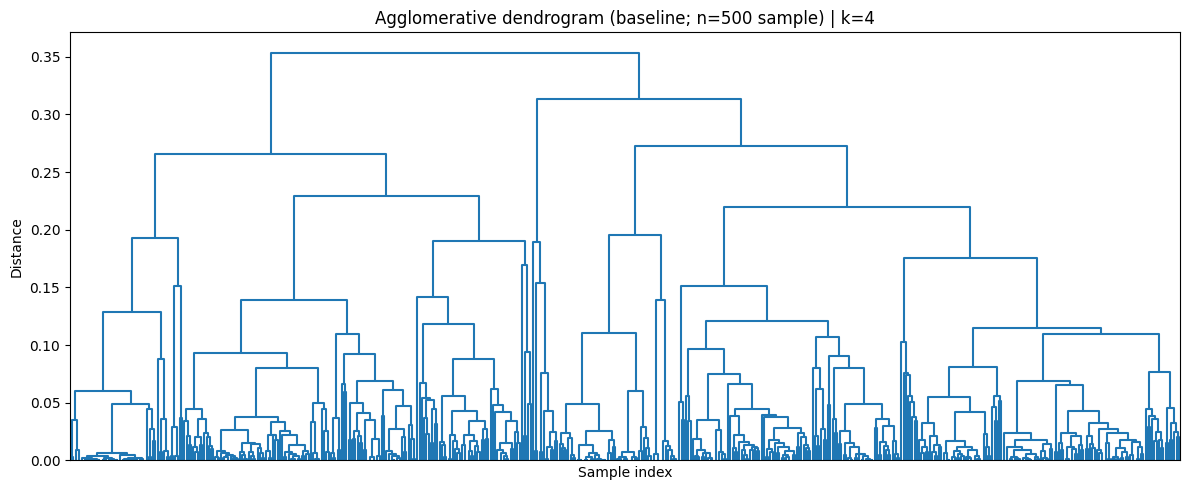

In [8]:
# ---------------------------------------------------------------------------
# 7. Baseline clustering (NO outlier removal): choose K, plot dendrogram, assign labels
# ---------------------------------------------------------------------------
# We already computed silhouette (k=2..8) in Section 6. Here we set a baseline K for
# interpretability and for detecting singleton outliers.
K_BASELINE = 4  # k=2 is too coarse; k=4 matches the classmate example and is more interpretable
candidates["cluster"] = fcluster(linkage_matrix, K_BASELINE, criterion="maxclust")

# Dendrogram (subsample for readability)
n_plot = min(500, len(candidates))
idx_plot = np.random.RandomState(42).choice(len(candidates), n_plot, replace=False)
D_sub = D[np.ix_(idx_plot, idx_plot)]
linkage_sub = linkage(squareform(D_sub, checks=False), method="average")
plt.figure(figsize=(12, 5))
dendrogram(linkage_sub, no_labels=True, color_threshold=0)
plt.title(f"Agglomerative dendrogram (baseline; n={n_plot} sample) | k={K_BASELINE}")
plt.xlabel("Sample index")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

In [9]:
# ---------------------------------------------------------------------------
# 8. Baseline singleton inspection (based on Section 7 baseline labels)
# ---------------------------------------------------------------------------
baseline_sizes = candidates["cluster"].value_counts().sort_index()
print("Baseline cluster sizes (number of candidates per cluster):")
print(baseline_sizes)

singleton_clusters = baseline_sizes[baseline_sizes == 1].index.tolist()
print("\nBaseline singleton clusters:", singleton_clusters)

for cid in singleton_clusters:
    print(f"\n=== Details for singleton cluster {cid} ===")
    cols_to_show = ["CANDIDATE_ID"] + retained_numeric + [
        "age", "gender", "ethnicity", "last_year_income", "highest_grade_completed", "c_state"
    ]
    existing_cols = [c for c in cols_to_show if c in candidates.columns]
    display(candidates.loc[candidates["cluster"] == cid, existing_cols])

Baseline cluster sizes (number of candidates per cluster):
cluster
1      76
2    2088
3    1533
4       1
Name: count, dtype: int64

Baseline singleton clusters: [4]

=== Details for singleton cluster 4 ===


,CANDIDATE_ID,avg_score,pass_rate,college_ready_rate,avg_retakes,credential_earned,pct_online,used_ged_ready,has_prep_center,age,gender,ethnicity,last_year_income,highest_grade_completed,c_state
2702,6590053,170.307692,1.0,0.692308,18.5,1,0.0,1,1,20,1,3,0,6,UNKNOWN


Baseline singleton clusters: [4]
Outlier candidate IDs removed: [6590053]
Candidates before: 3698 after removal: 3697
Filtered cluster matrix: 3697 x 8

Silhouette results on filtered set (k=2..8):
 k  avg_silhouette
 2        0.428861
 3        0.391542
 4        0.430324
 5        0.406475
 6        0.460231
 7        0.516026
 8        0.504678
Selected best_k (max silhouette): 7


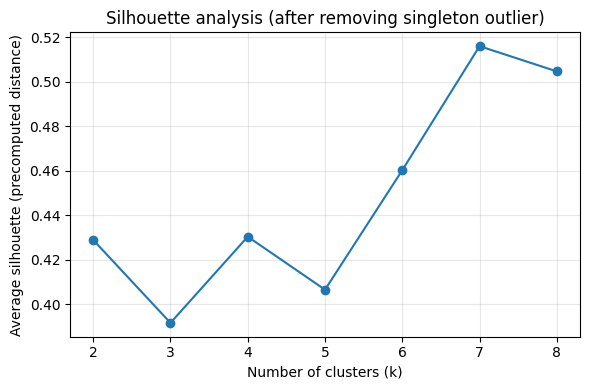

In [10]:
# ---------------------------------------------------------------------------
# 10. Remove singleton outlier candidate(s), then pick the best k (k=2..8)
#     using the SAME retained features and preprocessing rules
# ---------------------------------------------------------------------------

# 10.1 Identify singleton cluster(s) from Section 8, then remove those candidate(s)
baseline_sizes = candidates["cluster"].value_counts().sort_index()
singleton_clusters = baseline_sizes[baseline_sizes == 1].index.tolist()
outlier_ids = candidates.loc[candidates["cluster"].isin(singleton_clusters), "CANDIDATE_ID"].tolist()

print("Baseline singleton clusters:", singleton_clusters)
print("Outlier candidate IDs removed:", outlier_ids)

candidates_filtered = candidates[~candidates["CANDIDATE_ID"].isin(outlier_ids)].copy()
print("Candidates before:", len(candidates), "after removal:", len(candidates_filtered))

# 10.2 Rebuild the clustering matrix on the filtered set
# NOTE: We reuse retained_numeric from Section 4.
retained_numeric_filtered = retained_numeric

binary_candidates = [
    "used_ged_ready", "studied_for_ged", "has_prep_center", "credential_earned",
    "study_helpful_adult_education_class", "study_books", "study_helpful_online_course_video_study_materials",
]
binary_cols = [c for c in binary_candidates if c in retained_numeric_filtered]
continuous_cols = [c for c in retained_numeric_filtered if c not in binary_cols]
subject_score_cols = ["score_math", "score_science", "score_reasoning", "score_social_studies"]

cluster_df_filtered = candidates_filtered[["CANDIDATE_ID"] + retained_numeric_filtered].copy()

# Continuous: z-score; non-subject NA -> 0; subject scores keep NA
for col in continuous_cols:
    vals = cluster_df_filtered[col].dropna()
    if len(vals) > 0 and vals.std() > 0:
        cluster_df_filtered[col] = (cluster_df_filtered[col] - vals.mean()) / vals.std()
for col in continuous_cols:
    if col not in subject_score_cols:
        cluster_df_filtered[col] = cluster_df_filtered[col].fillna(0)

# Binary: keep 0/1
for col in binary_cols:
    cluster_df_filtered[col] = cluster_df_filtered[col].fillna(0).astype(int)

print("Filtered cluster matrix:", cluster_df_filtered.shape[0], "x", len(retained_numeric_filtered))

# 10.3 Gower distance + silhouette for k=2..8
X_cluster_filtered = cluster_df_filtered[retained_numeric_filtered].copy()
D_filtered = gower.gower_matrix(X_cluster_filtered)
linkage_filtered = linkage(squareform(D_filtered, checks=False), method="average")

sil_results_filtered = []
for k in range(2, 9):
    labels_k = fcluster(linkage_filtered, k, criterion="maxclust")
    sil_results_filtered.append({"k": k, "avg_silhouette": silhouette_score(D_filtered, labels_k, metric="precomputed")})

sil_df_filtered = pd.DataFrame(sil_results_filtered)
best_k = int(sil_df_filtered.loc[sil_df_filtered["avg_silhouette"].idxmax(), "k"])

print("\nSilhouette results on filtered set (k=2..8):")
print(sil_df_filtered.to_string(index=False))
print("Selected best_k (max silhouette):", best_k)

plt.figure(figsize=(6, 4))
plt.plot(sil_df_filtered["k"], sil_df_filtered["avg_silhouette"], marker="o")
plt.title("Silhouette analysis (after removing singleton outlier)")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Average silhouette (precomputed distance)")
plt.xticks(list(range(2, 9)))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Using SELECTED_K: 4

Final cluster sizes:
cluster
1     415
2    1118
3    1667
4     497
Name: count, dtype: int64


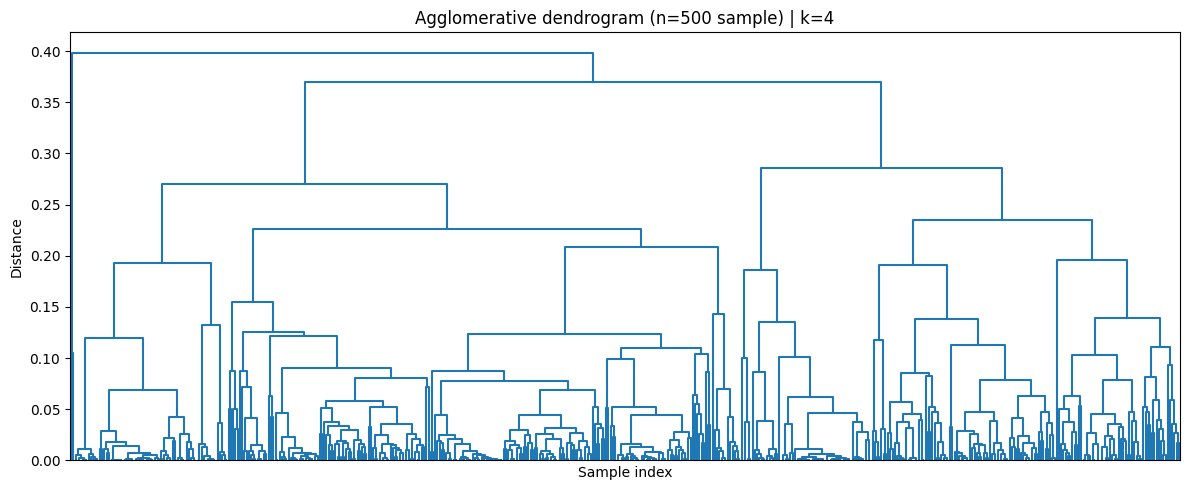

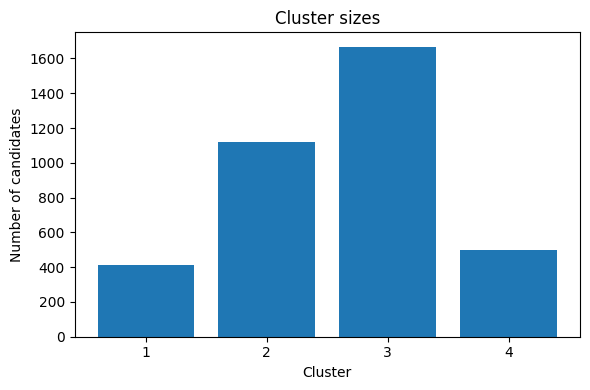

--- Performance (clustering features) ---
            N  Avg_Score Pass_Rate College_Ready Credential_Earned  \
cluster                                                              
1         415   157.1162     93.8%         19.9%            100.0%   
2        1118   155.6158     88.4%         18.2%            100.0%   
3        1667   146.2461     53.2%          6.3%              0.0%   
4         497   145.0541     39.4%          3.9%              0.0%   

         Avg_Retakes Pct_Online Used_GED_Ready Has_Prep_Center  
cluster                                                         
1             0.1024       0.0%           0.0%           12.3%  
2             1.3630      13.7%         100.0%           37.8%  
3             0.8635       4.9%         100.0%           42.8%  
4             0.2181       0.0%           0.0%           20.3%  

--- Subject scores ---
         score_math  score_science  score_reasoning  score_social_studies
cluster                                          

In [11]:
# ---------------------------------------------------------------------------
# 11. Final clustering with selected k (best silhouette) + plots + post-hoc tables
# ---------------------------------------------------------------------------

SELECTED_K = 4
print("Using SELECTED_K:", SELECTED_K)

# Assign clusters on the filtered set
candidates_final = candidates_filtered.copy()
candidates_final["cluster"] = fcluster(linkage_filtered, SELECTED_K, criterion="maxclust")

# Save final feature list for downstream steps (e.g., saving outputs)
retained_numeric_final = retained_numeric_filtered

print("\nFinal cluster sizes:")
print(candidates_final["cluster"].value_counts().sort_index())

# --- Plot dendrogram on a sample (readability)
np.random.seed(42)
n_plot = min(500, len(candidates_final))
idx_plot = np.random.choice(len(candidates_final), n_plot, replace=False)
D_sub = D_filtered[np.ix_(idx_plot, idx_plot)]
linkage_sub = linkage(squareform(D_sub, checks=False), method="average")

plt.figure(figsize=(12, 5))
dendrogram(linkage_sub, no_labels=True, color_threshold=0)
plt.title(f"Agglomerative dendrogram (n={n_plot} sample) | k={SELECTED_K}")
plt.xlabel("Sample index")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

# --- Cluster size bar chart
sizes = candidates_final["cluster"].value_counts().sort_index()
plt.figure(figsize=(6, 4))
plt.bar(sizes.index.astype(str), sizes.values)
plt.title("Cluster sizes")
plt.xlabel("Cluster")
plt.ylabel("Number of candidates")
plt.tight_layout()
plt.show()


# ---------------------------------------------------------------------------
# Post-hoc summary tables (same structure as Section 8, based on candidates_final)
# ---------------------------------------------------------------------------

def fmt_pct(x: float) -> str:
    return f"{x:.1%}"

print("--- Performance (clustering features) ---")
t1 = candidates_final.groupby("cluster").agg(
    N=("CANDIDATE_ID", "count"),
    Avg_Score=("avg_score", "mean"),
    Pass_Rate=("pass_rate", "mean"),
    College_Ready=("college_ready_rate", "mean"),
    Credential_Earned=("credential_earned", "mean"),
    Avg_Retakes=("avg_retakes", "mean"),
    Pct_Online=("pct_online", "mean"),
    Used_GED_Ready=("used_ged_ready", "mean"),
    Has_Prep_Center=("has_prep_center", "mean"),
).round(4)

# Format rates for readability
for c in ["Pass_Rate", "College_Ready", "Credential_Earned", "Pct_Online", "Used_GED_Ready", "Has_Prep_Center"]:
    t1[c] = t1[c].apply(fmt_pct)
print(t1)

# Subject scores (if present)
subj_cols = [c for c in ["score_math", "score_science", "score_reasoning", "score_social_studies"] if c in candidates_final.columns]
if subj_cols:
    print("\n--- Subject scores ---")
    t2 = candidates_final.groupby("cluster")[subj_cols].mean().round(1)
    print(t2)

# Preparation (post-hoc)
prep_cols = [c for c in [
    "studied_for_ged",
    "study_helpful_adult_education_class",
    "study_books",
    "study_helpful_online_course_video_study_materials",
] if c in candidates_final.columns]
if prep_cols:
    print("\n--- Preparation behaviors (post-hoc) ---")
    t3 = candidates_final.groupby("cluster")[prep_cols].mean().round(4)
    for c in prep_cols:
        t3[c] = t3[c].apply(fmt_pct)
    print(t3)

# Demographics (post-hoc)
print("\n--- Demographics (post-hoc) ---")
demo = candidates_final.groupby("cluster").agg(
    Avg_Age=("age", "mean"),
    Male=("gender", lambda x: (x == 1).mean()),
    Female=("gender", lambda x: (x == 2).mean()),
    Black=("african_american", lambda x: (x == 1).mean()),
    White=("white", lambda x: (x == 1).mean()),
    Hispanic=("ethnicity", lambda x: (x == 2).mean()),
).round(4)
for c in ["Male", "Female", "Black", "White", "Hispanic"]:
    demo[c] = demo[c].apply(fmt_pct)
print(demo)


In [12]:
# ---------------------------------------------------------------------------
# 11b. Cluster naming — performance tier + behavioral trait
# ---------------------------------------------------------------------------
# Part 1: performance tier ranked by avg_score (1 = best).
# Part 2: most distinctive behavioral trait by largest |z-score| vs sample mean.
#         Direction of z-score picks positive or negative label.
# Only clustering features (pct_online, used_ged_ready, has_prep_center,
# avg_retakes) are eligible — study behaviors are post-hoc only.

import numpy as np
import pandas as pd

profile = candidates_final.groupby("cluster").agg(
    n=("CANDIDATE_ID","count"),
    avg_score=("avg_score","mean"),
    avg_retakes=("avg_retakes","mean"),
    pct_online=("pct_online","mean"),
    pct_ged_ready=("used_ged_ready","mean"),
    pct_prep_center=("has_prep_center","mean"),
).reset_index()
profile = profile.sort_values("avg_score", ascending=False).reset_index(drop=True)
profile["perf_rank"] = range(1, len(profile)+1)

ALL_TIERS = [
    "High Achievers","Strong Performers","Solid Performers","Developing Learners",
    "Below Average Learners","Struggling Learners","At-Risk Candidates","Critical Needs",
]
tier_names = ALL_TIERS[:len(profile)]

TRAIT_COLS = ["pct_online","pct_ged_ready","pct_prep_center","avg_retakes"]
TRAIT_POS  = {"pct_online":"Online-Heavy","pct_ged_ready":"GED Ready Users",
               "pct_prep_center":"Prep Supported","avg_retakes":"High Retakers"}
TRAIT_NEG  = {"pct_online":"In-Person Testers","pct_ged_ready":"No GED Ready",
               "pct_prep_center":"No Prep Center","avg_retakes":"First-Attempt Passers"}

benchmarks = {
    "pct_online":     candidates_final["pct_online"].mean(),
    "pct_ged_ready":  candidates_final["used_ged_ready"].mean(),
    "pct_prep_center":candidates_final["has_prep_center"].mean(),
    "avg_retakes":    candidates_final["avg_retakes"].mean(),
}

def pick_trait(row):
    z = {}
    for feat in TRAIT_COLS:
        sd = profile[feat].std(ddof=0)
        z[feat] = (row[feat] - benchmarks[feat]) / sd if sd > 0 else 0.0
    best = max(z, key=lambda f: abs(z[f]))
    return TRAIT_POS[best] if z[best] >= 0 else TRAIT_NEG[best]

profile["tier"]  = [tier_names[r-1] for r in profile["perf_rank"]]
profile["trait"] = profile.apply(pick_trait, axis=1)
profile["cluster_name"] = profile["tier"] + " \u2014 " + profile["trait"]

# Deduplicate if two clusters get same name
seen = {}
for i, row in profile.iterrows():
    nm = row["cluster_name"]
    seen[nm] = seen.get(nm, 0) + 1
    if seen[nm] > 1:
        profile.at[i, "cluster_name"] = f"{nm} ({seen[nm]})"

name_map = dict(zip(profile["cluster"], profile["cluster_name"]))
candidates_final["cluster_name"] = candidates_final["cluster"].map(name_map)

print("Cluster names assigned:")
display(profile[["cluster","cluster_name","n","avg_score",
                 "pct_ged_ready","pct_prep_center","avg_retakes"]].round(3))


Cluster names assigned:


,cluster,cluster_name,n,avg_score,pct_ged_ready,pct_prep_center,avg_retakes
0,1,High Achievers — No Prep Center,415,157.116,0.0,0.123,0.102
1,2,Strong Performers — Online-Heavy,1118,155.616,1.0,0.377,1.363
2,3,Solid Performers — Prep Supported,1667,146.246,1.0,0.428,0.864
3,4,Developing Learners — No GED Ready,497,145.054,0.0,0.203,0.218


In [13]:
# ---------------------------------------------------------------------------
# 11c. Post-hoc demographic disparity analysis
# ---------------------------------------------------------------------------
# View A (col %): composition of each cluster by group.
# View B (row %): distribution of each group across clusters — the disparity
#                 lens. Groups overrepresented in the bottom cluster(s)
#                 relative to their overall sample share signal disadvantage.
#
# Variables: Ethnicity/Race | Age Group | Highest Grade | Income | Geography
# Clusters ordered left to right: best avg_score → worst avg_score.

import pandas as pd
import numpy as np
from IPython.display import display

# Cluster order: best to worst avg_score
perf_order = (
    candidates_final.groupby("cluster")["avg_score"].mean()
    .sort_values(ascending=False).index.tolist()
)

def show_disparity(df, col, label, drop_unk=True):
    d = df[["cluster", col]].dropna().copy()
    if drop_unk:
        d = d[~d[col].astype(str).isin(
            ["Unknown","Decline","Declined","Not Reported","Multiracial/Other"])]
    tab = (d.groupby([col,"cluster"]).size()
            .unstack(fill_value=0)
            .reindex(columns=perf_order, fill_value=0))
    tab = tab[[c for c in perf_order if c in tab.columns]]
    col_tot = tab.sum(axis=0)
    row_tot = tab.sum(axis=1)
    grand   = tab.values.sum()

    col_pct = tab.div(col_tot, axis=1).mul(100).round(1)
    col_pct.columns = [f"C{c} (n={col_tot[c]})" for c in col_pct.columns]

    row_pct = tab.div(row_tot, axis=0).mul(100).round(1)
    row_pct.columns = [f"C{c}" for c in row_pct.columns]
    row_pct["Overall%"] = (row_tot / grand * 100).round(1)
    row_pct["N"]        = row_tot.astype(int)

    sep = "-" * 70
    print(f"\n{sep}\n  {label.upper()}\n{sep}")
    print("View A: % of each cluster made up by this group")
    display(col_pct.style.format("{:.1f}%"))
    print("\nView B: % of each group in each cluster  (disparity lens)")
    display(row_pct.style.format({c:"{:.1f}%" for c in row_pct.columns if c != "N"}))
    return tab, row_tot, grand

# ── Derive grouping columns ───────────────────────────────────────────────────
# Race / ethnicity (already on candidates_final via race_category from cell 3)
candidates_final["ethnicity_race"] = candidates_final["race_category"]

# Age group
bins_age   = [0, 19, 24, 29, 39, 49, 999]
labels_age = ["Under 20","20-24","25-29","30-39","40-49","50+"]
candidates_final["age_group"] = pd.cut(
    candidates_final["age"], bins=bins_age, labels=labels_age, right=True
).astype(str)

# Education level
def _ed(g):
    if pd.isna(g) or g == 0: return "Unknown"
    g = int(g)
    if g in (1,2):  return "8th Grade or Below"
    if g == 3:      return "9th Grade"
    if g == 4:      return "10th Grade"
    if g == 5:      return "11th Grade"
    if g == 6:      return "12th Grade (no diploma)"
    return "Other / Never Attended"
candidates_final["ed_group"] = candidates_final["highest_grade_completed"].apply(_ed)

# Income group
def _inc(v):
    if pd.isna(v) or v == 0: return "Unknown / Not Reported"
    v = int(v)
    if v in (1,2): return "Under $10K"
    if v == 3:     return "$10K-$19,999"
    if v == 4:     return "$20K-$29,999"
    if v in (5,6): return "$30K-$49,999"
    return "$50K+"
candidates_final["income_group"] = candidates_final["last_year_income"].apply(_inc)

# ── Run tables ────────────────────────────────────────────────────────────────
print("=" * 70)
print("  POST-HOC DEMOGRAPHIC DISPARITY ANALYSIS")
print("  Columns: best avg_score (left) → worst avg_score (right)")
print("  Demographics were NOT used in clustering.")
print("=" * 70)

t_race,  rt_race,  gt_race  = show_disparity(candidates_final, "ethnicity_race", "Ethnicity / Race",       drop_unk=True)
t_age,   rt_age,   gt_age   = show_disparity(candidates_final, "age_group",      "Age Group",              drop_unk=False)
t_ed,    rt_ed,    gt_ed    = show_disparity(candidates_final, "ed_group",        "Highest Grade Completed",drop_unk=True)
print("\nNote: ~83% of candidates did not report income.")
t_inc,   rt_inc,   gt_inc   = show_disparity(candidates_final, "income_group",   "Income Level",           drop_unk=False)

# Geography
print(f"\n{'-'*70}\n  GEOGRAPHIC DISTRIBUTION\n{'-'*70}")
geo = candidates_final[candidates_final["census_region"] != "Other"]
t_reg, rt_reg, gt_reg = show_disparity(geo, "census_region", "Census Region", drop_unk=False)

top_sts = candidates_final["c_state"].value_counts().head(10).index.tolist()
t_st, rt_st, gt_st = show_disparity(
    candidates_final[candidates_final["c_state"].isin(top_sts)],
    "c_state", "Top 10 States", drop_unk=False)

# Overrepresentation summary
print(f"\n{'-'*70}\n  OVERREPRESENTATION SUMMARY — BOTTOM CLUSTER\n{'-'*70}")
bottom_c   = perf_order[-1]
bottom_n   = (candidates_final["cluster"] == bottom_c).sum()
total_n    = len(candidates_final)
exp_pct    = bottom_n / total_n * 100
bname      = candidates_final.loc[candidates_final["cluster"]==bottom_c,"cluster_name"].iloc[0]
b_score    = candidates_final.loc[candidates_final["cluster"]==bottom_c,"avg_score"].mean()
print(f"\nBottom cluster: C{bottom_c} — {bname}")
print(f"n = {bottom_n}  |  avg score = {b_score:.1f}  |  Expected rate = {exp_pct:.1f}%\n")

rows_s = []
for var, vl in [("ethnicity_race","Ethnicity/Race"),("age_group","Age Group"),
                ("ed_group","Education"),("income_group","Income")]:
    sub = candidates_final[["cluster",var]].dropna()
    sub = sub[~sub[var].astype(str).isin(
        ["Unknown","Decline","Declined","Not Reported","Unknown / Not Reported"])]
    for grp, gdf in sub.groupby(var):
        ng = len(gdf); nb = (gdf["cluster"]==bottom_c).sum()
        if ng < 30: continue
        gap = nb/ng*100 - exp_pct
        rows_s.append({"Variable":vl,"Group":str(grp),
                       "Bottom%": f"{nb/ng*100:.1f}%",
                       "Overall%":f"{ng/total_n*100:.1f}%",
                       "Gap(pp)": f"+{gap:.1f}","N":ng,"_gap":gap})

summ_s = (pd.DataFrame(rows_s).query("_gap > 0")
           .sort_values("_gap",ascending=False)
           .drop(columns="_gap").reset_index(drop=True))
print("Groups overrepresented in the bottom cluster (sorted by gap):\n")
display(summ_s)
print("\nGap(pp) = pp above expected rate. Larger = more disadvantaged.")


  POST-HOC DEMOGRAPHIC DISPARITY ANALYSIS
  Columns: best avg_score (left) → worst avg_score (right)
  Demographics were NOT used in clustering.

----------------------------------------------------------------------
  ETHNICITY / RACE
----------------------------------------------------------------------
View A: % of each cluster made up by this group


,C1 (n=314),C2 (n=835),C3 (n=1239),C4 (n=348)
ethnicity_race,,,,
Asian,2.2%,2.8%,3.0%,4.0%
Black,21.7%,16.6%,30.1%,42.8%
Black Hispanic,1.0%,1.4%,1.0%,4.6%
Hispanic,9.9%,12.0%,14.9%,14.1%
Native American,1.3%,1.6%,2.4%,1.1%
Pacific Islander,0.3%,0.4%,0.5%,0.6%
White,63.7%,65.3%,48.2%,32.8%



View B: % of each group in each cluster  (disparity lens)


,C1,C2,C3,C4,Overall%,N
ethnicity_race,,,,,,
Asian,8.6%,28.4%,45.7%,17.3%,3.0%,81
Black,9.3%,19.1%,51.2%,20.4%,26.6%,729
Black Hispanic,7.0%,27.9%,27.9%,37.2%,1.6%,43
Hispanic,8.5%,27.5%,50.5%,13.5%,13.3%,364
Native American,7.8%,25.5%,58.8%,7.8%,1.9%,51
Pacific Islander,8.3%,25.0%,50.0%,16.7%,0.4%,12
White,13.7%,37.4%,41.0%,7.8%,53.2%,1456



----------------------------------------------------------------------
  AGE GROUP
----------------------------------------------------------------------
View A: % of each cluster made up by this group


...


View B: % of each group in each cluster  (disparity lens)


,C1,C2,C3,C4,Overall%,N
c_state,,,,,,
AZ,11.8%,27.6%,41.8%,18.8%,8.1%,170
CA,9.5%,25.2%,57.1%,8.2%,15.0%,317
CO,10.2%,28.9%,53.9%,7.0%,6.1%,128
FL,12.5%,36.3%,42.9%,8.3%,21.6%,457
GA,17.0%,25.3%,40.1%,17.7%,13.1%,277
IL,10.2%,24.7%,51.8%,13.3%,7.9%,166
MI,11.0%,23.6%,52.8%,12.6%,6.0%,127
NY,8.2%,4.6%,19.4%,67.9%,9.3%,196
OH,19.0%,24.6%,40.8%,15.5%,6.7%,142



----------------------------------------------------------------------
  OVERREPRESENTATION SUMMARY — BOTTOM CLUSTER
----------------------------------------------------------------------

Bottom cluster: C4 — Developing Learners — No GED Ready
n = 497  |  avg score = 145.1  |  Expected rate = 13.4%

Groups overrepresented in the bottom cluster (sorted by gap):



,Variable,Group,Bottom%,Overall%,Gap(pp),N
0,Ethnicity/Race,Black Hispanic,37.2%,1.2%,+23.8,43
1,Ethnicity/Race,Black,20.4%,19.7%,+7.0,729
2,Age Group,50+,19.6%,5.4%,+6.2,199
3,Ethnicity/Race,Asian,17.3%,2.2%,+3.8,81
4,Age Group,30-39,16.9%,21.6%,+3.5,797
5,Education,Other / Never Attended,16.4%,8.6%,+3.0,317
6,Age Group,40-49,16.0%,12.0%,+2.6,443
7,Education,9th Grade,15.7%,12.3%,+2.2,453
8,Education,10th Grade,14.7%,24.3%,+1.2,899
9,Age Group,25-29,14.0%,17.2%,+0.6,635



Gap(pp) = pp above expected rate. Larger = more disadvantaged.


In [14]:
# ---------------------------------------------------------------------------
# 12. Cluster × Feature contribution matrix 
# ---------------------------------------------------------------------------
# Output (as requested):
# - Contribution rate matrix (%) only (rows = clusters, columns = features; each row sums to 100%)
# - A heatmap visualization of the contribution rates
# - A compact summary table: Top features per cluster with contribution %
#
# Notes:
# - Continuous features: use z-score, then impact = cluster mean z
# - Binary features: impact = standardized proportion difference vs overall proportion
# - Contribution rate per cluster = |impact| / sum(|impact|) across features in that cluster

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def _is_binary_series(s: pd.Series) -> bool:
    x = s.dropna().unique()
    if len(x) == 0:
        return False
    return set(x).issubset({0, 1})


cluster_col = "cluster"
if cluster_col not in candidates_final.columns:
    raise KeyError("Expected 'candidates_final' with a 'cluster' column. Run Section 11 first.")

features = list(retained_numeric_final)
clusters = sorted(candidates_final[cluster_col].dropna().unique())

# Split features
binary_feats = [f for f in features if _is_binary_series(candidates_final[f])]
cont_feats = [f for f in features if f not in binary_feats]

# --- Continuous: z-score (same idea as clustering matrix)
Z = pd.DataFrame(index=candidates_final.index)
if cont_feats:
    mu = candidates_final[cont_feats].mean(skipna=True)
    sd = candidates_final[cont_feats].std(skipna=True, ddof=0).replace(0, np.nan)
    Z[cont_feats] = (candidates_final[cont_feats] - mu) / sd

# --- Binary: keep as 0/1
if binary_feats:
    Z[binary_feats] = candidates_final[binary_feats].astype(float)

# --- Cluster centroids (means)
centroids = Z.groupby(candidates_final[cluster_col]).mean(numeric_only=True)
centroids = centroids.reindex(clusters)

# --- Impact definition (kept internally; we do not print signed impact)
impact = pd.DataFrame(index=clusters, columns=features, dtype=float)

for f in cont_feats:
    impact[f] = centroids[f]

for f in binary_feats:
    p_overall = float(Z[f].mean(skipna=True))
    denom = np.sqrt(p_overall * (1 - p_overall))
    delta = centroids[f] - p_overall
    impact[f] = 0.0 if (denom == 0 or np.isnan(denom)) else (delta / denom)

# --- Contribution rate (%), per cluster row sums to 100%
abs_imp = impact.abs()
row_sums = abs_imp.sum(axis=1).replace(0, np.nan)
contrib_rate = abs_imp.div(row_sums, axis=0) * 100
contrib_out = contrib_rate.round(1)

print("\n=== Cluster × Feature contribution rate matrix (%, each row sums to 100) ===")
print(contrib_out)


# --- Text summary: Top-K features per cluster
TOP_K = 4
print("\n=== Top features per cluster (by contribution %) ===")
for c in clusters:
    top = contrib_out.loc[c].sort_values(ascending=False).head(TOP_K)
    msg = ", ".join([f"{feat} ({pct:.1f}%)" for feat, pct in top.items()])
    print(f"- Cluster {int(c)}: {msg}")



=== Cluster × Feature contribution rate matrix (%, each row sums to 100) ===
   avg_score  pass_rate  college_ready_rate  avg_retakes  credential_earned  \
1       10.0       11.8                 6.0         11.3               18.9   
2       11.7       14.2                 7.3         11.9               28.2   
3       13.8       13.8                 7.9          0.8               31.9   
4        8.7       13.6                 5.7         11.0               15.5   

   pct_online  used_ged_ready  has_prep_center  
1         6.7            27.8              7.5  
2        11.6            13.6              1.4  
3         3.7            21.7              6.4  
4         7.7            32.1              5.6  

=== Top features per cluster (by contribution %) ===
- Cluster 1: used_ged_ready (27.8%), credential_earned (18.9%), pass_rate (11.8%), avg_retakes (11.3%)
- Cluster 2: credential_earned (28.2%), pass_rate (14.2%), used_ged_ready (13.6%), avg_retakes (11.9%)
- Cluster 3: credenti

In [15]:
# ---------------------------------------------------------------------------
# 13. Export ONE final PDF report — with readable labels + interpretations
# ---------------------------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import textwrap
from matplotlib.backends.backend_pdf import PdfPages
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import squareform

PDF_PATH = "C:/Users/davey/OneDrive/Desktop/clustering_report_final.pdf"

# ── Human-readable feature name mapping ───────────────────────────────────────
FEATURE_LABELS = {
    "avg_score":          "Average Score",
    "pass_rate":          "Pass Rate",
    "college_ready_rate": "College Ready Rate",
    "avg_retakes":        "Average Retakes",
    "credential_earned":  "Credential Earned",
    "pct_online":         "% Online Testing",
    "used_ged_ready":     "Used GED Ready",
    "has_prep_center":    "Has Prep Center",
    "score_math":         "Math Score",
    "score_science":      "Science Score",
    "score_reasoning":    "Reasoning Score",
    "score_social_studies": "Social Studies Score",
    "studied_for_ged":    "Studied for GED",
    "study_helpful_adult_education_class":                 "Adult Ed Class",
    "study_books":                                         "Books / Print",
    "study_helpful_online_course_video_study_materials":   "Online Video",
    "pct_ged_ready":      "% Used GED Ready",
    "pct_prep_center":    "% Has Prep Center",
    "Avg_Score":          "Average Score",
    "Pass_Rate":          "Pass Rate",
    "College_Ready":      "College Ready Rate",
    "Cred_Earned":        "Credential Earned",
    "Total_Attempts":     "Total Attempts",
    "Avg_Retakes":        "Average Retakes",
    "Avg_Age":            "Average Age",
    "pct_ged_ready":      "% Used GED Ready",
    "avg_retakes":        "Average Retakes",
    "pct_online":         "% Online Testing",
    "pct_prep_center":    "% Has Prep Center",
}

def relabel(df):
    """Rename both index and columns using FEATURE_LABELS where available."""
    df = df.copy()
    df.columns = [FEATURE_LABELS.get(str(c), str(c)) for c in df.columns]
    if df.index.name in FEATURE_LABELS:
        df.index.name = FEATURE_LABELS[df.index.name]
    df.index = [FEATURE_LABELS.get(str(i), str(i)) for i in df.index]
    return df

# ── helpers ───────────────────────────────────────────────────────────────────

def text_page(pdf, title, text, fs=9.5):
    # Split table body from interpretation section so each can be formatted
    if "\n" + "\u2500" * 70 + "\nINTERPRETATION\n" + "\u2500" * 70 + "\n" in text:
        parts = text.split("\n" + "\u2500" * 70 + "\nINTERPRETATION\n" + "\u2500" * 70 + "\n", 1)
        table_text = parts[0]
        interp_raw = parts[1] if len(parts) > 1 else ""
        interp_wrapped = wrap_interp(interp_raw, width=108)
        full_text = (table_text + "\n" + "\u2500" * 70 + "\nINTERPRETATION\n" + "\u2500" * 70 + "\n" + interp_wrapped)
    else:
        full_text = text
    fig = plt.figure(figsize=(11, 8.5))
    ax  = fig.add_subplot(111); ax.axis("off")
    ax.set_title(title, fontsize=13, pad=10, fontweight="bold")
    ax.text(0.01, 0.97, full_text, va="top", ha="left", family="monospace",
            fontsize=fs, transform=ax.transAxes)
    fig.tight_layout(); pdf.savefig(fig); plt.close(fig)

def df_page(pdf, title, df, interpretation="", fs=9):
    body = relabel(df).to_string()
    if interpretation:
        body += "\n" + "\u2500" * 70 + "\nINTERPRETATION\n" + "\u2500" * 70 + "\n" + interpretation
    text_page(pdf, title, body, fs=fs)

def disp_page(pdf, title, col_df, row_df, interpretation="", note=""):
    fig, axes = plt.subplots(3, 1, figsize=(11, 11),
                             gridspec_kw={"height_ratios": [2, 2, 1.2]})
    fig.suptitle(title, fontsize=12, fontweight="bold", y=0.99)
    for ax in axes: ax.axis("off")

    axes[0].text(0.0, 1.0, "View A — Cluster Composition (column %)",
                 fontsize=9, fontweight="bold", transform=axes[0].transAxes, va="top")
    axes[0].text(0.0, 0.88, col_df.to_string(), va="top", ha="left",
                 family="monospace", fontsize=8, transform=axes[0].transAxes)

    row_txt = row_df.to_string() + ("\n\n" + note if note else "")
    axes[1].text(0.0, 1.0, "View B — Group Distribution across clusters (row %)",
                 fontsize=9, fontweight="bold", transform=axes[1].transAxes, va="top")
    axes[1].text(0.0, 0.88, row_txt, va="top", ha="left",
                 family="monospace", fontsize=8, transform=axes[1].transAxes)

    if interpretation:
        interp_wrapped = wrap_interp(interpretation, width=110)
        interp_txt = "\u2500" * 70 + "\nINTERPRETATION\n" + "\u2500" * 70 + "\n" + interp_wrapped
        axes[2].text(0.0, 1.0, interp_txt, va="top", ha="left",
                     family="monospace", fontsize=8, transform=axes[2].transAxes)

    fig.tight_layout(rect=[0, 0, 1, 0.98]); pdf.savefig(fig); plt.close(fig)

def _find_cut_h(Z, k):
    u = np.unique(Z[:,2]); u.sort()
    cands = [float(u[0])-1e-6]
    for a,b in zip(u[:-1],u[1:]):
        if b>a: cands.append(float((a+b)/2))
    cands.append(float(u[-1])+1e-6)
    best_t, best_gap = cands[0], 1e9
    for t in cands:
        n = int(pd.Series(fcluster(Z,t,criterion="distance")).nunique())
        g = abs(n-int(k))
        if g < best_gap: best_gap,best_t = g,t
        if n == int(k): return t
    return best_t

def _is_bin(s):
    x = s.dropna().unique()
    return len(x)>0 and set(x).issubset({0,1})

def fmt(x): return f"{x:.1%}"

def wrap_interp(text, width=105):
    """Wrap interpretation text so no line exceeds `width` chars."""
    lines = []
    for para in text.split("\n"):
        if para.strip() == "":
            lines.append("")
        else:
            lines.extend(textwrap.wrap(para, width=width))
    return "\n".join(lines)

def make_disp_df(df, col, drop_unk=True):
    po = (df.groupby("cluster")["avg_score"].mean()
           .sort_values(ascending=False).index.tolist())
    d = df[["cluster",col]].dropna().copy()
    if drop_unk:
        d = d[~d[col].astype(str).isin(
            ["Unknown","Decline","Declined","Not Reported","Multiracial/Other"])]
    tab = (d.groupby([col,"cluster"]).size()
            .unstack(fill_value=0)
            .reindex(columns=po, fill_value=0))
    tab = tab[[c for c in po if c in tab.columns]]
    ct = tab.sum(axis=0); rt = tab.sum(axis=1); gt = tab.values.sum()
    cp = tab.div(ct,axis=1).mul(100).round(1)
    cp.columns = [f"C{c}(n={ct[c]})" for c in cp.columns]
    rp = tab.div(rt,axis=0).mul(100).round(1)
    rp.columns = [f"C{c}" for c in rp.columns]
    rp["Overall%"] = (rt/gt*100).round(1)
    rp["N"] = rt.astype(int)
    return cp, rp

# ── contribution matrix ───────────────────────────────────────────────────────
feats  = list(retained_numeric_final)
clus   = sorted(candidates_final["cluster"].dropna().unique())
bfeats = [f for f in feats if _is_bin(candidates_final[f])]
cfeats = [f for f in feats if f not in bfeats]
Zf = pd.DataFrame(index=candidates_final.index)
if cfeats:
    mu = candidates_final[cfeats].mean()
    sd = candidates_final[cfeats].std(ddof=0).replace(0,np.nan)
    Zf[cfeats] = (candidates_final[cfeats]-mu)/sd
if bfeats:
    Zf[bfeats] = candidates_final[bfeats].astype(float)
cents  = Zf.groupby(candidates_final["cluster"]).mean().reindex(clus)
imp    = pd.DataFrame(index=clus,columns=feats,dtype=float)
for f in cfeats: imp[f] = cents[f]
for f in bfeats:
    p = float(Zf[f].mean()); d = np.sqrt(p*(1-p))
    imp[f] = 0.0 if (d==0 or np.isnan(d)) else (cents[f]-p)/d
ai    = imp.abs()
contrib = (ai.div(ai.sum(axis=1).replace(0,np.nan),axis=0)*100).round(1)
contrib.index = [f"C{c}" for c in contrib.index]
contrib.columns = [FEATURE_LABELS.get(f, f) for f in contrib.columns]

TOP_K = 4
top_ls = ["Top features per cluster (by contribution %)"]
for c in clus:
    row = contrib.loc[f"C{c}"].sort_values(ascending=False).head(TOP_K)
    top_ls.append(f"  C{int(c)}: " + ", ".join(f"{f} ({v:.1f}%)" for f,v in row.items()))

# ── bottom cluster overrepresentation ────────────────────────────────────────
po_pdf = (candidates_final.groupby("cluster")["avg_score"].mean()
          .sort_values(ascending=False).index.tolist())
bot_c  = po_pdf[-1]
bot_n  = (candidates_final["cluster"]==bot_c).sum()
tot_n  = len(candidates_final); exp_p = bot_n/tot_n*100
bot_nm = candidates_final.loc[candidates_final["cluster"]==bot_c,"cluster_name"].iloc[0]
bot_sc = candidates_final.loc[candidates_final["cluster"]==bot_c,"avg_score"].mean()
srows  = []
for var,vl in [("ethnicity_race","Ethnicity/Race"),("age_group","Age Group"),
               ("ed_group","Education"),("income_group","Income")]:
    sub = candidates_final[["cluster",var]].dropna()
    sub = sub[~sub[var].astype(str).isin(
        ["Unknown","Decline","Declined","Not Reported","Unknown / Not Reported"])]
    for grp,gdf in sub.groupby(var):
        ng=len(gdf); nb=(gdf["cluster"]==bot_c).sum()
        if ng<30: continue
        gap = nb/ng*100 - exp_p
        srows.append({"Variable":vl,"Group":str(grp),
                      "Bottom Cluster %":f"{nb/ng*100:.1f}%",
                      "Overall %":f"{ng/tot_n*100:.1f}%",
                      "Gap (pp)":f"+{gap:.1f}","N":ng,"_g":gap})
summ_df = (pd.DataFrame(srows).query("_g>0").sort_values("_g",ascending=False)
           .drop(columns="_g").reset_index(drop=True))
summ_hdr = (f"Bottom cluster: C{bot_c} — {bot_nm}\n"
            f"n = {bot_n}  |  Average Score = {bot_sc:.1f}  |  "
            f"Expected rate in bottom cluster = {exp_p:.1f}%\n"
            "Gap (pp) = percentage points above expected rate.\n\n")

# ── dendrogram setup ─────────────────────────────────────────────────────────
np.random.seed(42)
n_pl  = min(500, len(candidates_final))
i_pl  = np.random.choice(len(candidates_final), n_pl, replace=False)
D_pl  = D_filtered[np.ix_(i_pl, i_pl)]
lk_pl = linkage(squareform(D_pl, checks=False), method="average")
cut_h = _find_cut_h(lk_pl, int(SELECTED_K))

intro_txt = "\n".join([
    "Pipeline overview (action -> purpose):",
    "1) Load CSV -> validate columns",
    "2) Aggregate to candidate level (1 row per CANDIDATE_ID)",
    "3) Census region + race/ethnicity labels (post-hoc only)",
    "4) Stage 1: completeness filter (>=70% non-missing fields)",
    "5) Stage 2: drop records with no demographic identity",
    "6) Variance filter (CV>=0.15, protect avg_score)",
    "7) Correlation filter (|r|<=0.80, drop lower-variance of pair)",
    "8) Z-score continuous; binary stay 0/1; subject NA kept",
    "9) Gower distance matrix (handles mixed types natively)",
    "10) Baseline agglomerative (k=K_BASELINE) -> detect singletons",
    "11) Remove singletons; recompute Gower; silhouette k=2..8",
    "12) Cluster naming: performance tier + behavioral trait",
    "13) Post-hoc demographic disparity analysis",
    "14) Cluster x Feature contribution matrix",
])

# ── INTERPRETATIONS ───────────────────────────────────────────────────────────

interp_sizes = (
    "Four distinct candidate groups emerged from the clustering. C1 (High Achievers) is the "
    "smallest group (n=415) but achieves the highest average scores. C2 (Strong Performers) "
    "is the second-largest and also earns full credentials. C3 (Solid Performers) is the "
    "largest group (n=1,667) but earns 0% credentials despite scores near the passing threshold, "
    "suggesting an attrition pattern where candidates pass some subjects but never complete all "
    "four. C4 (Developing Learners) is the lowest-scoring group with no credential completion "
    "and no GED Ready access, the most resource-deprived cluster."
)

interp_perf = (
    "The 12-point score spread between C1 (157.1) and C4 (145.1) is the headline performance "
    "finding. Two groups (C1, C2) achieve 100% credential completion; two groups (C3, C4) "
    "achieve 0%. C3 is especially notable: its average score (146.2) is above the passing "
    "threshold of 145, yet no candidate earned a credential. With 1,667 candidates and 0.86 "
    "average retakes, these are engaged candidates who are passing individual subjects but "
    "stalling before completing all four, the completion barrier is behavioural or structural, "
    "not academic. C2's high retake rate (1.36) shows that persistence, not first-attempt "
    "success, drives completion for the largest credentialed group."
)

interp_subj = (
    "Math is the weakest subject across all clusters, every cluster scores lower in Math than "
    "in any other subject. C4 (145.1 average score) averages only 142.0 in Math, which is below "
    "the 145 passing threshold, making Math the primary barrier to credential completion for "
    "this group. C3 averages 144.2 in Math, also below passing, reinforcing that Math is the "
    "subject most likely preventing the large non-credentialed group from finishing. C1 and C2 "
    "score consistently above 153 across all subjects, with Social Studies the highest-scoring "
    "subject for both top clusters."
)

interp_prep = (
    "Study rates are nearly identical across all clusters (78-82%), meaning reported study effort "
    "alone does not differentiate who succeeds. The more informative finding is in method: "
    "C4 has the highest Adult Education class usage (36%) but the lowest scores and zero "
    "credentials, suggesting adult ed programs serving this group may not be translating to "
    "exam outcomes. Online video usage is lowest for C4 (13.5%) despite it being associated "
    "with score gains in the EDA findings, this is a direct, addressable gap. C1 achieves "
    "the best outcomes with relatively low adult ed usage, pointing to a self-directed "
    "learner profile."
)

interp_demo = (
    "Age rises steadily from the best-performing to worst-performing cluster: C1 and C2 "
    "average 27.7 years; C3 averages 30.8; C4 averages 31.9. Older candidates face larger "
    "gaps since leaving school and more competing life obligations. The racial composition "
    "shift is the most policy-significant finding: C1 is 57% White and 17% Black; C4 is "
    "33% White and 34% Black. Black candidates are nearly twice as concentrated in the "
    "bottom cluster relative to the top cluster. Hispanic representation also rises from "
    "C1 (13.7%) to C3 (24.8%). Because these demographics were not inputs to the model, "
    "this concentration pattern is a genuine discovery, not a modeling artefact."
)

interp_naming = (
    "C1 is named 'No Prep Center' because its most distinctive behavioral feature is the "
    "near-total absence of prep center usage (12.3%), yet it achieves the best outcomes, "
    "confirming these are self-sufficient learners who succeed without institutional support. "
    "C2 is 'Online-Heavy' due to its distinctively high online testing rate and full GED Ready "
    "engagement (100%). C3 is 'Prep Supported' with 42.8% prep center access and 100% GED Ready "
    "usage, yet 0% credential completion, the support infrastructure is present but something "
    "else is preventing the finish. C4 is 'No GED Ready' with 0% GED Ready usage, the starkest "
    "resource gap in the model."
)

n_note_str = (
    "Note on sample sizes: the n shown in each column header may be smaller than "
    "the full cluster size. This is because candidates who did not report or declined "
    "to provide this demographic information are excluded before the percentages are "
    "calculated. Only candidates with a known value are counted, which ensures the "
    "disparity percentages reflect actual reported demographics rather than being "
    "diluted by non-responses."
)

interp_ethnicity = (
    "View A shows Black candidates make up 42.8% of C4 (the bottom cluster) but only 21.7% "
    "of C1. View B is the key disparity lens: 20.4% of all Black candidates landed in C4 "
    "versus only 7.8% of White candidates, a gap of over 12 percentage points. Black Hispanic "
    "candidates show the most extreme pattern: 37.2% in C4 against an overall sample share of "
    "just 1.2%. White candidates are strongly concentrated in C1 (13.7%) and C2 (37.4%), the "
    "two fully credentialed clusters. Hispanic candidates land primarily in C3 (50.5%), the "
    "large non-credentialed group. These patterns emerged without race being an input to the "
    "model, making them genuine structural findings."
)

interp_age = (
    "Younger candidates (20-24, Under 20) are the most represented in the top two clusters: "
    "nearly half of C1 and C2 are aged 20-24. The 50+ group shows the most pronounced "
    "bottom-cluster concentration: 19.6% in C4 versus an expected rate of 13.4%, a gap of "
    "+6.2 pp. The gradient is clear, the older the age group, the more likely they are to "
    "appear in C3 or C4. Candidates 30 and over increasingly concentrate in the lower-performing "
    "clusters, likely reflecting longer school-exit gaps, heavier life obligations, and "
    "reduced familiarity with digital testing environments."
)

interp_ed = (
    "Education level shows a weaker separation than race or age, with all groups distributed "
    "broadly across clusters. However, the '8th Grade or Below' group has the highest C3 "
    "concentration (52.0%), meaning candidates with the least prior schooling are most likely "
    "to enter the large stalled group, passing some subjects but not completing. The '9th Grade' "
    "group also shows elevated C3 and C4 rates. Notably, '12th Grade (no diploma)' candidates "
    "— those who came closest to finishing high school, perform comparably to 10th and 11th "
    "grade candidates, suggesting prior schooling level alone does not determine GED success "
    "once basic threshold exposure is reached."
)

interp_income = (
    "Income data is heavily limited by non-disclosure (83% unknown), so these findings are "
    "directional rather than definitive. Among those who reported, candidates earning Under $10K "
    "have the highest bottom-cluster rate (10.7%) of all reporters. Higher income reporters "
    "($30K-$49,999 and $50K+) are more concentrated in C1 and C2, the credentialed clusters. "
    "The 'Unknown / Not Reported' group has a C4 rate of 14.2%, slightly above the expected "
    "rate of 13.4%, suggesting that non-disclosers are marginally more concentrated at the "
    "bottom, possibly reflecting lower engagement or socioeconomic vulnerability. Income "
    "non-reporting itself rises from 73.7% in C1 to 87.9% in C4, suggesting engagement "
    "differences between clusters."
)

interp_region = (
    "The Northeast stands out sharply: 36.6% of Northeastern candidates land in C4, compared "
    "to only 8-11% for all other regions. The Northeast is 32.2% of C4's composition despite "
    "being only 11.7% of the total sample, a 3x overrepresentation. This is almost entirely "
    "driven by New York (see Top 10 States). The South and West are the most evenly distributed "
    "regions, with candidates spread across clusters roughly in proportion to their sample share. "
    "The Midwest shows slightly elevated C3 concentration (50.5%), pointing to higher rates of "
    "the stalled non-credentialed pattern in that region."
)

interp_states = (
    "New York is the most extreme outlier: 67.9% of NY candidates land in C4, making it by far "
    "the highest bottom-cluster concentration of any state. NY makes up 37.6% of C4 despite "
    "being only 9.3% of the total sample. This pattern was visible in the DIANA analysis as well "
    "and likely reflects a combination of state-level program differences, testing centre access "
    "issues, or a different candidate population profile in NY. Florida and Oregon show the "
    "strongest top-cluster representation (FL: 36.3% in C2; OR: 43.5% in C2). California "
    "concentrates in C3 (57.1%), the large stalled group."
)

interp_overrep = (
    "The top finding is Black Hispanic candidates: 37.2% in the bottom cluster against a 1.2% "
    "overall share, a gap of +23.8 pp, nearly 3x the expected rate. Black candidates show a "
    "+7.0 pp gap. The 50+ age group shows +6.2 pp. Taken together, the groups most "
    "disadvantaged relative to their sample share are: Black and Black Hispanic candidates, "
    "older learners (30+), those who never formally attended school, and candidates who left "
    "education before 10th grade. These groups share a common profile: limited academic "
    "foundation, older age, and no GED Ready access. Interventions targeting GED Ready "
    "adoption in this population would address the most actionable gap."
)

interp_contrib = (
    "Credential Earned is the dominant driver for C2 and C3, these clusters are most "
    "distinctively defined by whether candidates finished or not. Used GED Ready dominates "
    "C1 and C4: C1 is defined by its absence (0% GED Ready, yet full credentials), while C4 "
    "is also defined by its absence but with the worst outcomes. This contrast shows that "
    "GED Ready absence has completely different implications depending on the candidate "
    "profile, high achievers don't need it; the lowest performers lack it entirely. "
    "Average Score and Pass Rate contribute relatively evenly across clusters, "
    "meaning score differences alone do not fully explain cluster identity, "
    "the combination of credential completion, resource access, and retake behaviour "
    "together define each group."
)

interp_top = (
    "Across all four clusters, Used GED Ready and Credential Earned appear in the top 4 "
    "features, confirming that platform access and completion status are the two most "
    "structurally important variables in this dataset. Average Retakes features in every "
    "cluster's top 4, highlighting that persistence patterns are a consistent differentiator. "
    "C3 (Solid Performers, Prep Supported) is uniquely defined by Credential Earned (31.9%) "
    "and Used GED Ready (21.7%), its identity is almost entirely about what it lacks "
    "(completion) and what it has (GED Ready). Addressing the completion gap for C3 is "
    "the single highest-leverage intervention in this dataset."
)

# ── write PDF ─────────────────────────────────────────────────────────────────
with PdfPages(PDF_PATH) as pdf:

    # Page 1: Introduction
    text_page(pdf, "Introduction — Pipeline Overview", intro_txt)

    # Page 2: Dendrogram
    fig = plt.figure(figsize=(11, 8.5)); ax = fig.add_subplot(111)
    dendrogram(lk_pl, no_labels=True, color_threshold=cut_h,
               truncate_mode="level", p=30, ax=ax)
    ax.axhline(y=cut_h, color="red", linestyle="--", lw=1.8, label=f"k={SELECTED_K} cut")
    ax.legend(fontsize=9)
    ax.set_title(f"Agglomerative Dendrogram  n={n_pl} sample  k={SELECTED_K}")
    ax.set_xlabel("Sample index (truncated)"); ax.set_ylabel("Distance")
    fig.tight_layout(); pdf.savefig(fig); plt.close(fig)

    # Page 3: Cluster sizes + names
    sz = (candidates_final.groupby("cluster")
          .agg(N=("CANDIDATE_ID","count"), Name=("cluster_name","first"),
               Average_Score=("avg_score","mean"))
          .round(2).sort_values("Average_Score", ascending=False))
    df_page(pdf, f"Cluster Sizes and Names  (k={SELECTED_K})", sz,
            interpretation=interp_sizes)

    # Page 4: Performance
    perf_p = candidates_final.groupby("cluster").agg(
        N=("CANDIDATE_ID","count"), Name=("cluster_name","first"),
        Average_Score=("avg_score","mean"), Pass_Rate=("pass_rate","mean"),
        College_Ready_Rate=("college_ready_rate","mean"),
        Credential_Earned=("credential_earned","mean"),
        Total_Attempts=("total_attempts","mean"),
        Average_Retakes=("avg_retakes","mean"),
    ).round(4)
    for c in ["Pass_Rate","College_Ready_Rate","Credential_Earned"]:
        perf_p[c] = perf_p[c].apply(fmt)
    df_page(pdf, "Performance Summary (clustering features)", perf_p,
            interpretation=interp_perf)

    # Page 5: Subject scores
    sc = [c for c in ["score_math","score_science","score_reasoning",
                      "score_social_studies"] if c in candidates_final.columns]
    if sc:
        subj_p = candidates_final.groupby("cluster")[sc].mean().round(1)
        subj_p.columns = [FEATURE_LABELS.get(c,c) for c in subj_p.columns]
        df_page(pdf, "Subject Scores  (pass threshold = 145)", subj_p,
                interpretation=interp_subj)

    # Page 6: Prep behaviors
    pc = [c for c in ["studied_for_ged","study_helpful_adult_education_class",
                       "study_books","study_helpful_online_course_video_study_materials"]
          if c in candidates_final.columns]
    if pc:
        prep_p = candidates_final.groupby("cluster")[pc].mean().round(4)
        for c in pc: prep_p[c] = prep_p[c].apply(fmt)
        prep_p.columns = [FEATURE_LABELS.get(c,c) for c in prep_p.columns]
        df_page(pdf, "Preparation Behaviors (post-hoc)", prep_p,
                interpretation=interp_prep)

    # Page 7: Demographics
    dm = candidates_final.groupby("cluster").agg(
        Average_Age=("age","mean"),
        Male=("gender",lambda x:(x==1).mean()),
        Female=("gender",lambda x:(x==2).mean()),
        Black=("african_american",lambda x:(x==1).mean()),
        White=("white",lambda x:(x==1).mean()),
        Hispanic=("ethnicity",lambda x:(x==2).mean()),
    ).round(4)
    for c in ["Male","Female","Black","White","Hispanic"]: dm[c]=dm[c].apply(fmt)
    df_page(pdf, "Demographics (post-hoc — not used in clustering)", dm,
            interpretation=interp_demo)

    # Page 8: Naming profile
    prf = profile[["cluster","cluster_name","n","avg_score",
                   "pct_ged_ready","pct_prep_center","avg_retakes"]].copy()
    prf.columns = ["Cluster","Name","N","Average Score",
                   "% Used GED Ready","% Has Prep Center","Average Retakes"]
    df_page(pdf, "Cluster Naming Profile", prf, interpretation=interp_naming)

    # Pages 9-12: Disparity tables
    for var, vlabel, du, note, interp in [
        ("ethnicity_race","Ethnicity / Race",    True,  "",                         interp_ethnicity),
        ("age_group",     "Age Group",           False, "",                         interp_age),
        ("ed_group",      "Highest Grade Completed", True, "",                     interp_ed),
        ("income_group",  "Income Level",        False, "~83% did not report income.", interp_income),
    ]:
        cp2, rp2 = make_disp_df(candidates_final, var, drop_unk=du)
        disp_page(pdf, f"Disparity — {vlabel}", cp2, rp2,
                  interpretation=interp, note=note)

    # Pages 13-14: Geography
    geo_df = candidates_final[candidates_final["census_region"]!="Other"]
    cp_r, rp_r = make_disp_df(geo_df, "census_region", drop_unk=False)
    disp_page(pdf, "Geographic Distribution — Census Region", cp_r, rp_r,
              interpretation=interp_region)

    top_sts = candidates_final["c_state"].value_counts().head(10).index.tolist()
    st_df = candidates_final[candidates_final["c_state"].isin(top_sts)]
    cp_s, rp_s = make_disp_df(st_df, "c_state", drop_unk=False)
    disp_page(pdf, "Geographic Distribution — Top 10 States", cp_s, rp_s,
              interpretation=interp_states)

    # Page 15: Overrepresentation
    body15 = summ_hdr + summ_df.to_string()
    body15 += "\n" + "\u2500" * 70 + "\nINTERPRETATION\n" + "\u2500" * 70 + "\n" + wrap_interp(interp_overrep, width=108)
    text_page(pdf, "Overrepresentation in Bottom Cluster", body15)

    # Page 16: Contribution matrix
    df_page(pdf, "Cluster x Feature Contribution Matrix (%)", contrib,
            interpretation=interp_contrib)

    # Page 17: Heatmap
    fig, ax = plt.subplots(figsize=(11, 8.5))
    im = ax.imshow(contrib.values.astype(float), aspect="auto", cmap="viridis")
    fig.colorbar(im, ax=ax, label="Contribution rate (%)")
    ax.set_xticks(range(len(contrib.columns)))
    ax.set_xticklabels(contrib.columns, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(len(contrib.index)))
    ax.set_yticklabels(contrib.index)
    ax.set_title("Cluster x Feature Contribution Rates (heatmap)")
    fig.tight_layout(); pdf.savefig(fig); plt.close(fig)

    # Page 18: Top features
    top_body = "\n".join(top_ls) + "\n" + "\u2500" * 70 + "\nINTERPRETATION\n" + "\u2500" * 70 + "\n" + wrap_interp(interp_top, width=108)
    text_page(pdf, "Top Features per Cluster (by Contribution %)", top_body)

print(f"PDF saved: {PDF_PATH}  |  18 pages")


PDF saved: C:/Users/davey/OneDrive/Desktop/clustering_report_final.pdf  |  18 pages
